In [ ]:
# Made originally by Fernando Vizeu at https://github.com/giecaruff/PasseyTOCMethod
# Adapted on GIECAR
from stoneforge.reservoir.toc_v import TOCProcessor
from stoneforge.data_management.preprocessing import DataLoader
from stoneforge.vis.plot_welllog import LogPlot

import numpy as np
import pandas as pd

In [ ]:
# Data access and processing
las_path = r"https://raw.githubusercontent.com/giecaruff/datasets/refs/heads/main/wells/las2/npra/DP1.las"
csv_path = r"https://raw.githubusercontent.com/giecaruff/datasets/refs/heads/main/wells/tab/evaluation/synth_toc_1300_3000.csv"

las2 = DataLoader(las_path, filetype='las2')
depth = las2.data_obj.data['DEPT']['values']
dt = las2.data_obj.data['DT']['values']
gr = las2.data_obj.data['GR']['values']
logrt = np.log10(las2.data_obj.data['ILD']['values'])
cali = las2.data_obj.data['CALI']['values']

csv = pd.read_csv(csv_path, engine="python")
measured_cot_depth = np.array(csv['depth'])
measured_cot = np.array(csv['toc'])

In [ ]:
# Reestructurate data
dt_base = 90.0
res_base = 1.0
lom_val = 10.0
window_value = 100
depth_min = np.min(depth)
depth_max = np.max(depth)
plot_height = 650

processor = TOCProcessor(
        depth = depth,
        dt = dt,
        gr = gr,
        logrt = logrt,
        cali = cali,
        measured_cot = measured_cot,
        measured_cot_depth = measured_cot_depth,
        window_value = window_value,
        lom=lom_val,
        dt_baseline=dt_base,
        logrt_baseline=res_base,
        skip=1
    )

result = processor.run()

Figure size (depths and scales detected): 11.69 x 7.09 polegadas
Displaying figure... depth range:{self.range}


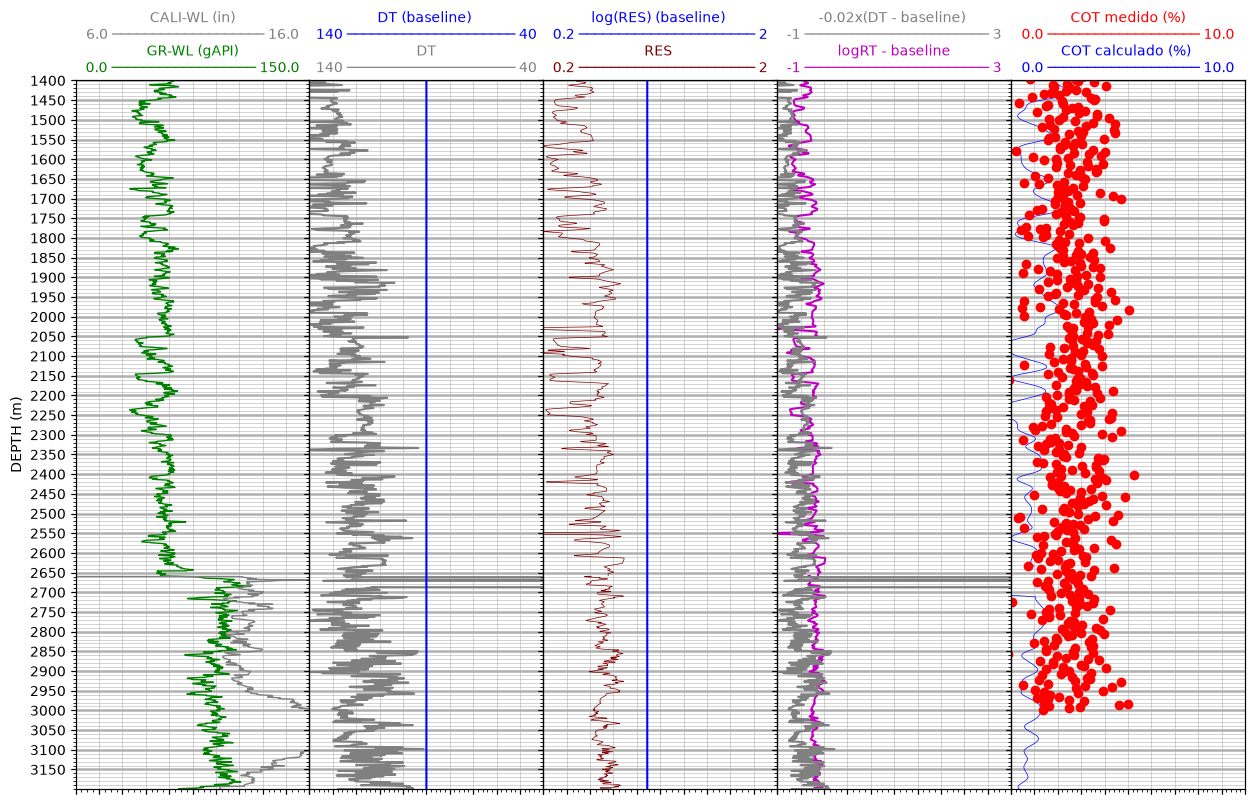

In [ ]:
# Graphics / visualization
img = LogPlot(res = 10000,size=(29.7, 30.0),top=1400, bot=3200, title=("",1.12))

img.set_depth(result['depth'], d="DEPTH (m)")
img.normal_plot(x=result['gr'],c='green',grid=1, lw=1., vmin=0., vmax=150., label='GR-WL (gAPI)')
img.normal_plot(x=result['cali'],c='grey',lw=1., vmin=6., vmax=16., label='CALI-WL (in)', track=True)

img.set_depth(result['depth'])
img.normal_plot(x = result['dt'],c='grey', grid=1, vmin=140, vmax=40, label='DT',lw=1.5)
img.normal_plot(x = result['dt_baseline'],c='blue', grid=1, vmin=140, vmax=40, label='DT (baseline)',lw=1.5, track=True)

img.set_depth(result['depth'])
img.normal_plot(x=result['logrt'],c='maroon', vmin=0.2, vmax=2, label='RES')
img.normal_plot(x = result['rt_baseline'],c='blue', grid=1, vmin=0.2, vmax=2, label='log(RES) (baseline)',lw=1.5, track=True)

img.set_depth(result['depth'])
img.normal_plot(x = result["logrt_minus_baseline"],c='m',grid=1,vmin=-1, vmax=3, label='logRT - baseline',lw=1.5)
img.normal_plot(x = result["dt_minus_baseline_scaled"],c='grey',grid=1, vmin=-1, vmax=3, label='-0.02x(DT - baseline)',lw=1.5, track=True)

img.set_depth(result['depth'])
img.normal_plot(x=result['calculated_cot_pct'],c='b', grid = 1, vmin=0., vmax=10., label='COT calculado (%)')
img.set_depth(result["measured_cot_depth"])
img.normal_plot(x=result["measured_cot_pct"],c='r', s="", m='o', grid = 1, vmin=0., vmax=10., label='COT medido (%)', track=True)

img.show()